In [33]:
import matplotlib.pyplot as plt
import numpy as np

In [34]:
x = np.array([4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9])
y = np.array([0.000196, -5.19505, -10.3689, -14.959, -18.4126, -20.25, -20.1243, -17.8711, -13.5425, -7.41942])
n = 10

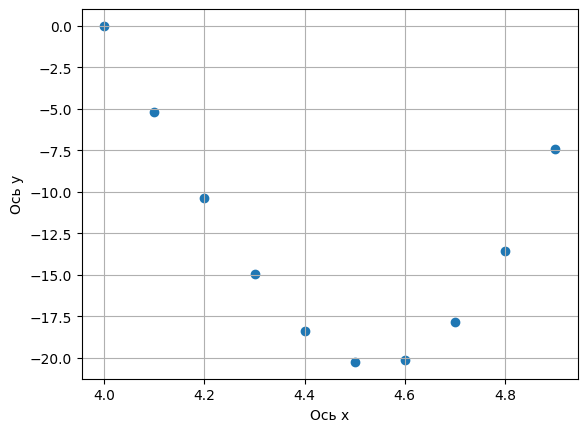

In [35]:
plt.figure(1)
plt.ylabel('Ось y')
plt.xlabel('Ось x')
plt.grid()
plt.scatter(x, y)
plt.show()

In [36]:
def p(i, t):
    c = 1
    s = 1
    for j in range(n):
        if j == i:
            continue
        c /= (x[i] - x[j])
        s *= (t - x[j])
    return c * s

In [37]:
def L(x):
    res = 0
    for i in range(n):
        res += p(i, x) * y[i]
    return res

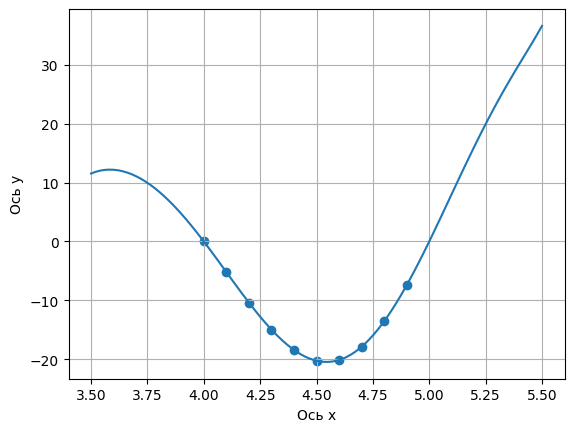

In [38]:
X = np.linspace(3.5, 5.5, 100)
Y = [L(x) for x in X]
plt.figure(1)
plt.ylabel('Ось y')
plt.xlabel('Ось x')
plt.grid()
plt.plot(X, Y)
plt.scatter(x, y)
plt.show()

In [39]:
step = 50

In [40]:
lny = np.log(y + step)
lnx = np.log(x)

In [41]:
A = (np.sum(lny) * np.sum(lnx) - np.sum(lnx * lny) * n ) / (np.sum(lnx) * np.sum(lnx) - np.sum(lnx * lnx) * n)
B = (np.sum(lny) - A * np.sum(lnx)) / n

In [42]:
a = np.exp(B)
b = A

In [43]:
def F(x):
    return a * x ** b - step

In [44]:
np.sqrt(np.sum((F(x) - y) ** 2) / n)

np.float64(5.570097529411788)

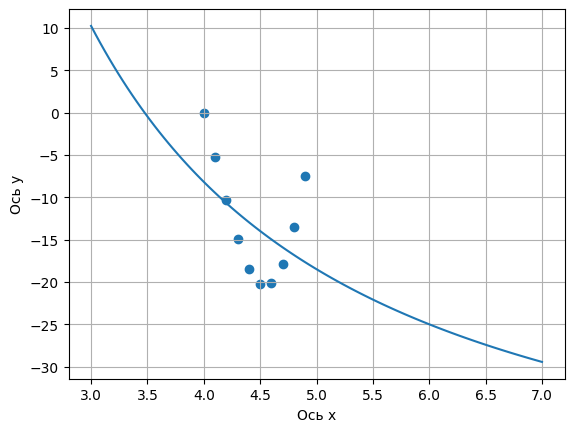

In [45]:
X = np.linspace(3, 7, 100)
Y = F(X)
plt.figure(1)
plt.ylabel('Ось y')
plt.xlabel('Ось x')
plt.grid()
plt.plot(X, Y)
plt.scatter(x, y)
plt.show()

In [46]:
y = y + 1
A = (np.sum(x / y) * n - np.sum(1 / y) * np.sum(x)) / (np.sum(x * x) * n - np.sum(x) * np.sum(x))
B  = (np.sum(1 / y) - A * np.sum(x)) / n
y = y - 1

In [47]:
a = 1 / A
b = a * B
a, b

(np.float64(-1.8356059548771317), np.float64(-4.473240047776393))

In [48]:
def G(x):
    return a / (x + b) - 1

In [49]:
np.sqrt(np.sum((G(x) - y) ** 2) / n)

np.float64(23.11536061250291)

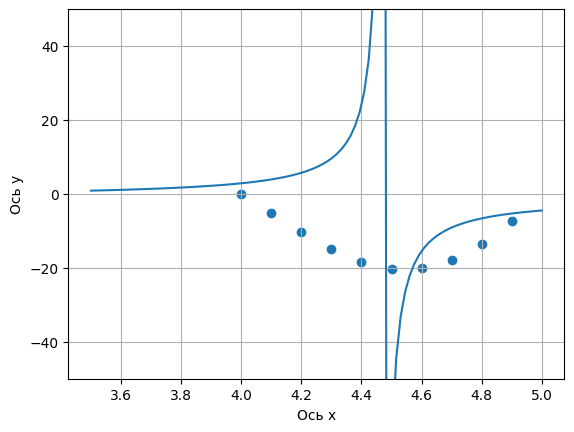

In [52]:
X = np.linspace(3.5, 5, 100)
Y = G(X)
plt.figure(1)
plt.ylabel('Ось y')
plt.xlabel('Ось x')
plt.ylim(-50, 50)
plt.grid()
plt.plot(X, Y)
plt.scatter(x, y)
plt.show()